<a href="https://colab.research.google.com/github/GurditSra/-python-assignments-portfolio/blob/main/Thermodynamics_Assignment_1_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermodynamics Assignment 1

### Cynthia Chung, Veronica Cui, Taren Ginter, Eric Pettipiece, Tushar Sood

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#for volume calculations we can use volume of a right cylinder
#V=np.pi*r**2*h
#r=radius, 7mm/2=0.35cm
#h=height, which is 10cm
#V=3.848cm^3=0.00385L

In [ ]:
r = 0.08314
R = 8.314
V_in = 0.00385 # volume of the piston (L)
A = np.pi*(0.0035)**2 # cross-sectional area of the piston
V_in_cm = 3.85 #volume in cm^3
V_in_m = 3.85/1000000

### Question 1

#### Question 1a

In [ ]:
# initial temp is 25 degrees (round it to 300 K)
Tmin = 300
Tmax = 730

dT   = 10
N    = int((Tmax - Tmin)/dT) + 1
T    = np.zeros(N)
T_   = Tmin

# creates an array of your temperature range from 300 K to 730 K with increments of 10 K
for i in range(0,N):
    T[i] = T_
    T_ += dT

In [ ]:
# heat capacity parameters for propane
a1 = -69.8
b1 = 278.2
c1 = 313
d1 = 390

# heat capacity parameters for oxygen
a2 = 20.6
b2 = 4.6
c2 = 5.19
d2 = 102

# heat capacity parameters for carbon dioxide
a3 = -20
b3 = 70
c3 = 50
d3 = 550

# heat capacity parameters for water
a4 = 20.4
b4 = 39.6
c4 = 2.6
d4 = 932

In [ ]:
CV_prop = np.zeros(N)
CV_O2 = np.zeros(N)
CV_CO2 = np.zeros(N)
CV_H2O = np.zeros(N)

for i in range(0,N):
    CV_prop[i] = (a1+(b1/(1+np.exp((-T[i]+c1)/d1))))
    CV_O2[i] = (a2+(b2/(1+np.exp((-T[i]+c2)/d2))))
    CV_CO2[i] = (a3+(b3/(1+np.exp((-T[i]+c3)/d3))))
    CV_H2O[i] = (a4+(b4/(1+np.exp((-T[i]+c4)/d4))))

In [ ]:
# total moles of reactants
n_reac=(1.00*0.00385)/(0.08314*298)

In [ ]:
# moles of propane
n_prop = n_reac/6

# moles of oxygen
n_O2 = n_reac*5/6

In [ ]:
# calculating the molar heat capacity of reactants
CVreac = n_prop*CV_prop+n_O2*CV_O2

In [ ]:
dS_V = np.zeros(N)
V = np.zeros(N)
P = np.zeros(N)
dS_V[0] = 0

# range is not inclusive so we add the last entry [-1] at the beginning
# here we break down the integral into a summation (the trapezoidal rule)
for i in range(0,N):
    dS_V[i] = dS_V[i-1] + (CVreac[i-1]/T[i-1] + CVreac[i]/T[i]) * dT * 0.5
    V[i] = V_in*np.exp(-dS_V[i]/(n_reac*R))
    P[i] = (n_reac*r*T[i])/V[i]

147.21354184847286


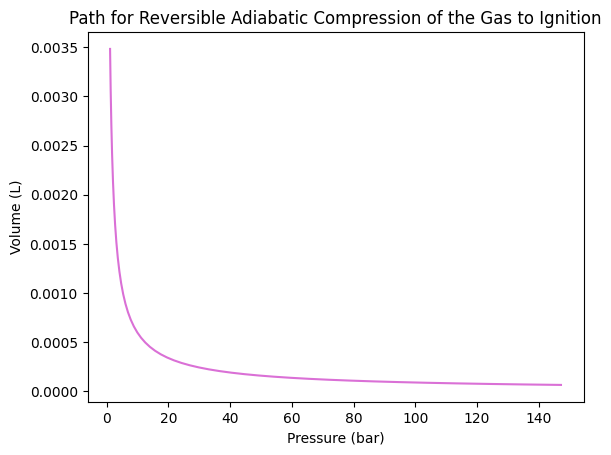

In [ ]:
plt.figure(1)
plt.xlabel('Pressure (bar)')
plt.ylabel('Volume (L)')
plt.title('Path for Reversible Adiabatic Compression of the Gas to Ignition')
plt.plot(P,V, color='orchid')
print(P[43])

#### Question 1b

In [ ]:
len(V) # determining the length of the array

44

In [ ]:
# compression ratio
CR=V_in/V[43]

In [ ]:
print(CR)

60.09539105595193


#### Question 1c

In [ ]:
# force
# 1 m^2*bar = 100000N
F=(P[43]*100000)*A

In [ ]:
print(F)

566.5441024356176


In [ ]:
F/5000

np.float64(0.11330882048712351)

### Question 2

#### Question 2a

In [ ]:
# enthalpy of formations
H_CO2 = -393.5
H_H2O = -241.8
H_prop = -103.8

# enthalpy
dH = (3*(H_CO2) + 4*(H_H2O) - (H_prop))*1000

#### Question 2b

In [ ]:
# change in energy
dE_in = dH - 1*R*298.15

In [ ]:
print(dE_in)

-2046378.8190999997


In [ ]:
dCV_reac = (3*CV_CO2 + 4*CV_H2O)-(1*CV_prop + 5*CV_O2)

In [ ]:
# calculating the change in energy at ignition temperature
dE_rxn = dE_in

for i in range(0,N):
    dE_rxn = dE_rxn + (dCV_reac[i-1] + dCV_reac[i]) * dT * 0.5

In [ ]:
print(dE_rxn)

-2029213.7227906205


### Question 3

#### Question 3a

In [ ]:
n_rxn = n_prop
heat = -n_rxn*dE_rxn

In [ ]:
Tmin2 = 730
Tmax2 = 8000

dT = 10
N2 = int((Tmax2 - Tmin2)/dT) + 1
T2 = np.zeros(N2)
T_ = Tmin2

for i in range(0,N2):
    T2[i] = T_
    T_ += dT

In [ ]:
CV_CO2_2 = np.zeros(N2)
CV_H2O_2 = np.zeros(N2)

for i in range(0,N2):
    CV_CO2_2[i] = (a3+(b3/(1+np.exp((-T2[i]+c3)/d3))))
    CV_H2O_2[i] = (a4+(b4/(1+np.exp((-T2[i]+c4)/d4))))

In [ ]:
CV_prod = 3*n_rxn*CV_CO2_2 + 4*n_rxn*CV_H2O_2

In [ ]:
dCV_prod = np.zeros(N2)

for i in range (1,N2):
    dCV_prod[i] = (CV_prod[i-1] + CV_prod[i]) * dT * 0.5
    heat -= dCV_prod[i]
    if heat < 0:
        TFlame = T2[i]
        break

In [ ]:
TFlame

np.float64(6160.0)

#### Question 3b

In [ ]:
# F = A*nRT/V
n_prod = 3*n_rxn + 4*n_rxn
# 1 m^2*bar = 100000N
F2 = 100000*A*n_prod*r*TFlame/V[43]

In [ ]:
print(F2)

5577.484405713202


### Question 4

In [ ]:
#initial temp is flame temp, final temp is that when the piston is at the original volume again
Tinitial = 6160
Tfinal = 3370

dT   = -10
N3    = int((Tfinal - Tinitial)/dT) + 1
T3    = np.zeros(N3)
T_   = Tinitial

# creates an array of your temperature range from 6160 K to 3370 K with increments of -10 K
for i in range(0,N3):
    T3[i] = T_
    T_ += dT

In [ ]:
#heat capacity calculations
CV_CO2_3 = np.zeros(N3)
CV_H2O_3 = np.zeros(N3)

for i in range(0,N3):
    CV_CO2_3[i] = (a3+(b3/(1+np.exp((-T3[i]+c3)/d3))))
    CV_H2O_3[i] = (a4+(b4/(1+np.exp((-T3[i]+c4)/d4))))

In [ ]:
CV_prod2 = 3*n_rxn*CV_CO2_3 + 4*n_rxn*CV_H2O_3

n_prod = 3*n_rxn + 4*n_rxn

In [ ]:
dS_V2 = np.zeros(N3)
V2 = np.zeros(N3)
P2 = np.zeros(N3)
dS_V2[0] = 0
V_in2 = V[43]

# range is not inclusive so we add the last entry [-1] at the beginning
# here we break down the integral into a summation (the trapezoidal rule)

for i in range(0,N3):
    if np.all(V2 <= 0.00385):
        dS_V2[i] = dS_V2[i-1] + (CV_prod2[i-1]/T3[i-1] + CV_prod2[i]/T3[i]) * dT * 0.5
        V2[i] = V_in2*np.exp(-dS_V2[i]/(n_prod*R))
        P2[i] = (n_prod*r*T3[i])/V2[i]
    else:
        break #the if condition inside the loop breaks it when the volume exceeds the original volume of the piston

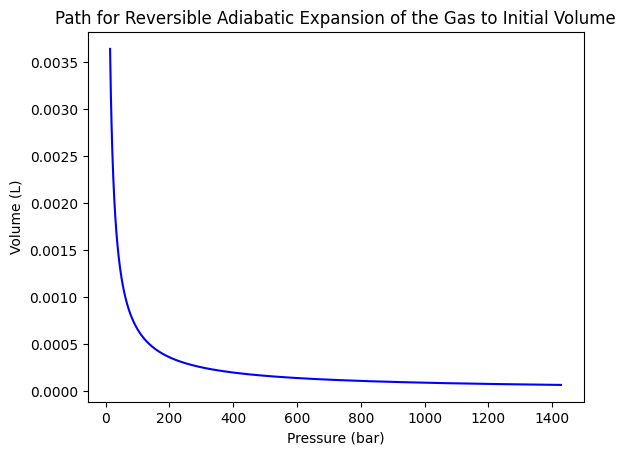

In [ ]:
plt.figure(2)
plt.xlabel('Pressure (bar)')
plt.ylabel('Volume (L)')
plt.title('Path for Reversible Adiabatic Expansion of the Gas to Initial Volume')
plt.plot(P2,V2, color='blue')

In [ ]:
V2[279] #point at which the volume exceeds the original volume of the piston

np.float64(0.003641442231576982)

### Question 5

In [ ]:
#determine the mass of the piston (solving for an answer in kg)
    #piston is composed osmium, osmium density is 22.5872g/cm^3
    #V_in_cm is the volume in cm^3 (which matches density), so we can multiply volume by density to solve for mass
    #the 0.001 factor accounts for g to kg conversion
mass=(V_in_cm)*22.5872*0.001

In [ ]:
print(mass) #in kg


0.08696071999999999


In [ ]:
#Now, we use the force, pressure, area, and mass relationships to solve for acceleration
#F_net=ma
#F_pressure=pressure*area
#When we equate these, a=(pressure*area)/mass
#For pressure, we need to import the array from question 4 to see our full values
#Since we want to examine the volume changes as well, we will also need out volume array from question 4
#For changes in volume, we can solve for the change in height using V=np.pi*r**2*h, so h=V/(np.pi*r**2) for each volume increment
#Once we examine arrays for change in volume and pressure, we can solve for our increments and use kinematics for the appropriate time interval

In [ ]:
print(V2) #volume array from question 4

[6.50499412e-05 6.57616425e-05 6.64823033e-05 6.72120511e-05
 6.79510154e-05 6.86993281e-05 6.94571228e-05 7.02245353e-05
 7.10017039e-05 7.17887687e-05 7.25858722e-05 7.33931594e-05
 7.42107772e-05 7.50388754e-05 7.58776057e-05 7.67271226e-05
 7.75875829e-05 7.84591462e-05 7.93419744e-05 8.02362322e-05
 8.11420870e-05 8.20597088e-05 8.29892706e-05 8.39309480e-05
 8.48849197e-05 8.58513671e-05 8.68304748e-05 8.78224304e-05
 8.88274244e-05 8.98456509e-05 9.08773067e-05 9.19225921e-05
 9.29817110e-05 9.40548702e-05 9.51422803e-05 9.62441553e-05
 9.73607128e-05 9.84921741e-05 9.96387641e-05 1.00800712e-04
 1.01978249e-04 1.03171614e-04 1.04381045e-04 1.05606789e-04
 1.06849093e-04 1.08108211e-04 1.09384400e-04 1.10677922e-04
 1.11989043e-04 1.13318034e-04 1.14665170e-04 1.16030732e-04
 1.17415003e-04 1.18818276e-04 1.20240843e-04 1.21683006e-04
 1.23145069e-04 1.24627344e-04 1.26130145e-04 1.27653795e-04
 1.29198620e-04 1.30764954e-04 1.32353134e-04 1.33963506e-04
 1.35596421e-04 1.372522

In [ ]:
print(P2) #pressure array from question 4

[1427.33218516 1409.5929496  1392.04594318 1374.68939053 1357.52152981
 1340.54061265 1323.74490407 1307.13268237 1290.70223907 1274.45187884
 1258.37991941 1242.48469147 1226.76453863 1211.2178173  1195.84289667
 1180.63815856 1165.60199739 1150.7328201  1136.02904605 1121.48910697
 1107.11144685 1092.89452192 1078.83680052 1064.93676303 1051.19290183
 1037.60372121 1024.16773728 1010.8834779   997.74948264  984.76430265
  971.92650064  959.23465078  946.68733863  934.28316108  922.02072626
  909.89865349  897.9155732   886.07012683  874.36096682  862.7867565
  851.34617003  840.03789231  828.86061896  817.8130562   806.89392082
  796.10194008  785.43585166  774.89440361  764.47635424  754.1804721
  744.00553587  733.95033434  724.01366628  714.19434046  704.49117552
  694.90299991  685.42865186  676.06697929  666.81683974  657.67710035
  648.64663773  639.72433796  630.90909647  622.19981805  613.5954167
  605.09481564  596.69694722  588.40075287  580.20518301  572.10919702
  564.111

In [ ]:
pressure=P2
list_acceleration = []
for i in pressure:
    acceleration = (((i-1)*100000)*A)/mass
    list_acceleration.append(acceleration)
    #the 100000 is the conversion from bar to pascal (1 Pa = 1 N/m^2)
    #i-1 account for gas pressure minus external pressure (1 bar)

In [ ]:
print(list_acceleration)

[np.float64(63122.40199084198), np.float64(62337.35123630588), np.float64(61560.807591971236), np.float64(60792.692488592926), np.float64(60032.927956227875), np.float64(59281.4366206307), np.float64(58538.14169966512), np.float64(57802.9669997314), np.float64(57075.83691220932), np.float64(56356.676409916996), np.float64(55645.41104358535), np.float64(54941.966938348094), np.float64(54246.270790247596), np.float64(53558.249862755925), np.float64(52877.831983311626), np.float64(52204.94553987192), np.float64(51539.519477480186), np.float64(50881.48329484905), np.float64(50230.76704095848), np.float64(49587.30131166952), np.float64(48951.01724635293), np.float64(48321.846524533255), np.float64(47699.721362547934), np.float64(47084.574510221515), np.float64(46476.339247555035), np.float64(45874.94938143023), np.float64(45280.339242329), np.float64(44692.44368106748), np.float64(44111.19806554529), np.float64(43536.538277509506), np.float64(42968.40070933339), np.float64(42406.72226081002

In [ ]:
volume=V2
list_height = []
for i in volume:
    vol=i*0.001 #to convert L (units of q4) to m^3 (for SI units)
    height = vol/((np.pi)*((0.0035)**2))
    list_height.append(height)

In [ ]:
print(list_height)
print(len(list_height))

[np.float64(0.0016902889289956637), np.float64(0.0017087821180345945), np.float64(0.0017275081136322243), np.float64(0.0017464702305443273), np.float64(0.0017656718361920528), np.float64(0.0017851163515855454), np.float64(0.0018048072522652899), np.float64(0.001824748069261542), np.float64(0.0018449423900722297), np.float64(0.0018653938596597042), np.float64(0.0018861061814667405), np.float64(0.0019070831184521873), np.float64(0.0019283284941466828), np.float64(0.0019498461937288542), np.float64(0.0019716401651224363), np.float64(0.001993714420114749), np.float64(0.0020160730354969827), np.float64(0.0020387201542267585), np.float64(0.002061659986613433), np.float64(0.0020848968115266273), np.float64(0.0021084349776284814), np.float64(0.002132278904630136), np.float64(0.0021564330845729547), np.float64(0.0021809020831350242), np.float64(0.0022056905409634678), np.float64(0.0022308031750331255), np.float64(0.002256244780032174), np.float64(0.0022820202297752566), np.float64(0.00230813447

In [ ]:
array_difheight=[]
for i in range(len(list_height)-1):
    difference_height = list_height[i+1]-list_height[i]
    array_difheight.append(difference_height)

In [ ]:
print(array_difheight)
print(len(array_difheight)) #use len to return number of items total

[np.float64(1.8493189038930845e-05), np.float64(1.8725995597629764e-05), np.float64(1.8962116912103017e-05), np.float64(1.9201605647725488e-05), np.float64(1.9444515393492613e-05), np.float64(1.9690900679744487e-05), np.float64(1.9940816996252093e-05), np.float64(2.0194320810687765e-05), np.float64(2.045146958747448e-05), np.float64(2.07123218070363e-05), np.float64(2.097693698544672e-05), np.float64(2.124537569449551e-05), np.float64(2.1517699582171467e-05), np.float64(2.1793971393582095e-05), np.float64(2.207425499231282e-05), np.float64(2.2358615382233552e-05), np.float64(2.2647118729775782e-05), np.float64(2.2939832386674377e-05), np.float64(2.323682491319444e-05), np.float64(2.353816610185409e-05), np.float64(2.3843927001654646e-05), np.float64(2.4154179942818647e-05), np.float64(2.446899856206955e-05), np.float64(2.478845782844354e-05), np.float64(2.5112634069657767e-05), np.float64(2.5441604999048434e-05), np.float64(2.5775449743082636e-05), np.float64(2.6114248869468695e-05), n

In [ ]:
#based on kinematics equations in class, we want to use the change in volume to solve final velocity
#here, we are using the i=0 case for the initial velocity of zero
#after this, the velocity builds up based on previous increments until we reach our final interaval

In [ ]:
velocity_current = []
for i in range(len(array_difheight)):
    if i == 0:
        velocity_current.append(np.sqrt(2*list_acceleration[i]*array_difheight[i]))
    else:
        velocity_current.append(np.sqrt((2*list_acceleration[i]*array_difheight[i])+(velocity_current[i-1]**2)))

print(velocity_current)

[np.float64(1.5279623768980868), np.float64(2.160862548811002), np.float64(2.646502109649424), np.float64(3.055913616455423), np.float64(3.416610954551348), np.float64(3.742704927730623), np.float64(4.042578003938387), np.float64(4.321691825747275), np.float64(4.583840062906888), np.float64(4.831784862539375), np.float64(5.067611421552148), np.float64(5.292939729285163), np.float64(5.509058076883982), np.float64(5.717011004474199), np.float64(5.917659361484039), np.float64(6.111722581671437), np.float64(6.2998092152919), np.float64(6.482439474905659), np.float64(6.660062208702527), np.float64(6.833067897615325), np.float64(7.001798758688989), np.float64(7.166556705240275), np.float64(7.327609694592566), np.float64(7.485196845475785), np.float64(7.639532604574895), np.float64(7.790810169641554), np.float64(7.939204325143107), np.float64(8.084873809164572), np.float64(8.227963302927522), np.float64(8.368605113961562), np.float64(8.506920608682524), np.float64(8.643021438522174), np.float

# Question 6

Text(0.5, 0, 'Pressure (bar)')

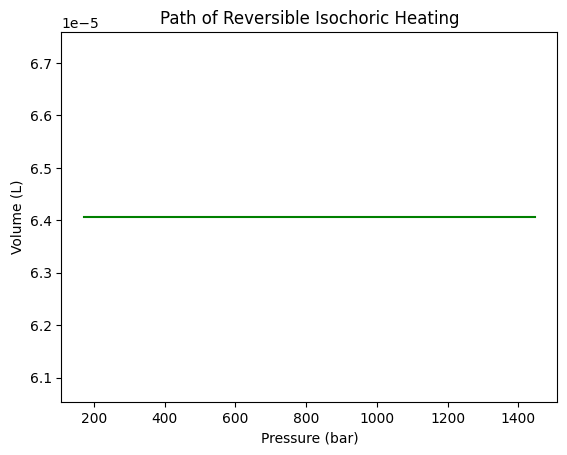

In [ ]:
#temperature array here is from the flame temperature to the ignition temperature of propane
#the intial volume is set to be the volume of the piston when it is fully compressed using the array previously calculated
Temp_iso = np.arange(730, 6160, 10)
V_in2 = V[43]

#pressure and volume calculations for the isochoric heating
deltaP = n_prod*r*Temp_iso/V_in2
V_con = 0*Temp_iso + V_in2

plt.plot(deltaP, V_con, color="green")
plt.title('Path of Reversible Isochoric Heating')
plt.ylabel('Volume (L)')
plt.xlabel('Pressure (bar)')


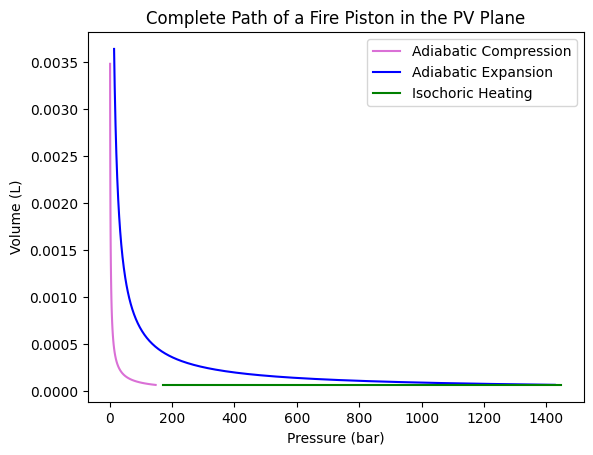

In [ ]:
a = plt.plot(P, V, color="orchid", label='Adiabatic Compression')
b = plt.plot(P2, V2, color="blue", label='Adiabatic Expansion')
c = plt.plot(deltaP, V_con, color="green", label='Isochoric Heating')
plt.title('Complete Path of a Fire Piston in the PV Plane')
plt.ylabel('Volume (L)')
plt.xlabel('Pressure (bar)')
plt.legend()
plt.show(a + b + c)